<a href="https://colab.research.google.com/github/Camiloflorez1/Algotitmos_Optiminzacion/blob/main/Trabajo_pr%C3%A1ctico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Trabajo práctico
Nombre: Jonathan Camilo Flórez Díaz <br>
Link:   https://colab.research.google.com/drive/19o2PEjDMjsSdRzJEGOfcxE1cBYgzJRWL?usp=sharing <br>
Github: https://github.com/Camiloflorez1/Algotitmos_Optiminzacion/blob/main/Trabajo_pr%C3%A1ctico.ipynb <br>



### Problema
####Problema 3. Generación de Tribunales(I)
- Se precisa configurar tribunales de evaluación para un grupo de 15 alumnos que desean
presentar su Trabajo Fin de Máster (TFM).
- Cada tribunal está compuesto por tres profesores, cada uno desempeñando uno de los
siguientes roles: Presidente, Secretario o Vocal.
- Los profesores han indicado su disponibilidad horaria para participar en los tribunales de
15h a 21h durante la semana del 15 al 19 de abril:

- Número de profesores : 10
- Número de tribunales : 15
- Disponibilidad/Roles : https://bit.ly/41QWk8o
- 1 indica que profesor tiene disponibilidad
- 0 en caso contrario

### Modelo
- ¿Como represento el espacio de soluciones?
Cada solución es representada por 15 posibles combinaciones (tribunales) con ternas de profesores que representan los roles P,S,V

- ¿Cual es la función objetivo?
La función objetivo en este caso es maximizar las soluciones válidas cuando el profesor tenga tiempo libre y pueda desempeñar el rol, se agregó ademas una penalización para que fuera menos probable repetir profesores y hacer un poco más justa la distribución

- ¿Como implemento las restricciones?
LAs restricciones se hicieron un poco dinámicas, la más importante para el código es una limitación de iteraciones, otra con base en generaciones que no aprendian nada nuevo y finalmente la más relevante para la lógica que es encontrar una solución óptioma que cumpla los criterios

### Análisis
- ¿Que complejidad tiene el problema?. Orden de complejidad y Contabilizar el espacio de
soluciones

La complejidad de este algoritmo es $O(n^k * m^{3k})$ siendo n el número de fechas posibles, k los tribunales necesarios y m los profesores disponibles.

Al final no fué si es evidente que a una mayor población el costo en tiempo es mayor, sin embargo no necesariamente una mayor poblasión encuentra más rápido una solución óptima, por lo que una poblasión pequeña (10 individuos) con al rededor 2 iteraciones encuentra una solución, pero si quisieramos ser más críticos de forma que las cargas sean equilibradas les tomaría aproximadamente 4 generaciones para encontrar una generación con cierto balance entre profesores

### Diseño
- ¿Que técnica utilizo? ¿Por qué?

En este caso decidí uzar un algoritmo genético por un motivo técnico y uno personal, si bien hay otros algoritmos que puedan llegar a una solución óptima este algoritmo permite muchas variaciones y decisiones a lo largo del proceso de herencia y combinacion lo que permite modificarlo y adaptarlo a cualquier particularidad del problema, no siendo demasiado costoso de implementar para este problema concreto. Sin emabrgo la principal razon para usar este método fué porque quizá es el algoritmo que más sirve para prácticar una optimización en esta materia y más retos me piondría al implementarlo.

In [1]:
# Cargar Información
# Decidí cargar todo en un diccionario por profesor sus posibles roles y la información de sus días si están disponibles o no
# Las categorías de los días y horas son un arreglo en texto dd-hh, ya que realmente es indiferente entender que representan días y horas decidí volverlos una etiqueta concreta
import io
import random
import pandas as pd
import numpy as np
from time import time
import matplotlib.pyplot as plt

df_roles = pd.read_csv(io.StringIO('''
Profesor,ROL
RRD,"P,S,V"
QYV,"P,S,V"
LHL,"P,V"
HLC,"S,V"
MSB,"P,S,V"
PMQ,"P,S,V"
QWF,"S,V"
EBB,"S,V"
IOE,"P,S,V"
IOA,"P,S,V"
'''))

df_abailability = pd.read_csv(io.StringIO('''
prof,15-15,15-16,15-17,15-18,15-19,15-20,15-21,16-15,16-16,16-17,16-18,16-19,16-20,16-21,17-15,17-16,17-17,17-18,17-19,17-20,17-21,18-15,18-16,18-17,18-18,18-19,18-20,18-21,19-15,19-16,19-17,19-18,19-19,19-20,19-21
RRD,0,1,1,1,0,1,1,1,0,1,1,1,1,1,1,1,0,0,1,0,1,0,1,1,1,1,1,1,1,1,1,1,1,0,0
QYV,1,1,1,1,0,0,0,0,1,1,1,1,0,0,1,0,0,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1
LHL,0,0,1,1,0,1,1,1,1,1,0,0,1,1,1,1,1,1,1,1,1,1,0,1,1,1,0,1,0,1,1,0,1,0,1
HLC,1,0,1,0,1,1,0,1,0,0,1,1,1,1,0,0,1,1,1,1,1,1,0,1,1,0,1,1,1,1,1,1,1,1,0
MSB,1,1,0,1,0,1,1,1,1,1,0,1,1,1,1,0,1,1,0,1,1,0,1,1,1,0,1,1,1,0,1,1,1,1,0
PMQ,1,1,1,1,1,0,0,1,1,1,1,1,1,1,1,1,0,0,1,1,1,1,1,1,0,0,1,1,1,1,1,0,1,0,1
QWF,0,1,1,1,1,1,1,1,1,0,1,1,0,1,0,0,1,1,0,0,1,1,0,0,0,0,1,1,1,1,1,1,1,0,1
EBB,1,1,1,1,1,0,0,1,1,0,1,1,1,0,1,1,1,0,0,1,1,0,1,1,1,1,1,1,0,1,1,1,0,1,0
IOE,1,0,1,1,0,1,0,0,1,1,1,1,1,1,1,1,0,0,0,1,1,1,1,1,1,1,1,0,1,0,1,1,1,1,1
IOA,1,1,0,1,1,0,1,1,0,0,0,0,0,1,1,1,0,0,1,1,1,1,0,0,1,1,1,1,1,1,1,0,0,0,1
'''))

dates = "15-15,15-16,15-17,15-18,15-19,15-20,15-21,16-15,16-16,16-17,16-18,16-19,16-20,16-21,17-15,17-16,17-17,17-18,17-19,17-20,17-21,18-15,18-16,18-17,18-18,18-19,18-20,18-21,19-15,19-16,19-17,19-18,19-19,19-20,19-21".split(",")
# roles = "P,S,V".split(",")
# spaces = [f"{date};{role}" for date in dates for role in roles]
tribunals = 15

profesors = {
    row['Profesor']: {
        "roles": set(row['ROL'].split(','))
    }
    for index, row in df_roles.iterrows()
}

columns = list(df_abailability.columns)
columns.remove("prof")
columns
for _, row in df_abailability.iterrows():
  profesors[row.prof]["availability"] = sorted([col for col in columns if row[col] == 1])

In [2]:
# función que determina si el profesor puede en ese rol y fecha
def can(prof, role, date):
  if role not in profesors[prof]["roles"] or date not in profesors[prof]["availability"]:
    return 0
  return 1

# Genera un individuo aleatorio: 15 tribunales, cada uno con una fecha y 3 profesores (P, S, V)
def generate_pair(inheritance=[]):
  inherited_dict = {}
  for d in inheritance:
    if isinstance(d, dict):
      inherited_dict.update(d)

  response = {}
  available_dates = list(dates)
  random.shuffle(available_dates)
  selected_dates = available_dates[:tribunals]

  for date in selected_dates:
    if date in inherited_dict:
      response[date] = inherited_dict[date]
    else:
      # Cada tribunal tiene 3 profesores: uno para P, uno para S, uno para V
      prof_list = list(profesors.keys())
      response[date] = {
          "P": str(np.random.choice(prof_list)),
          "S": str(np.random.choice(prof_list)),
          "V": str(np.random.choice(prof_list))
      }

  return response


# Clase para el individuo genético
# Cada tribunal es: {fecha: {"P": prof1, "S": prof2, "V": prof3}}
# El score evalúa si cada profesor puede cumplir su rol en esa fecha
class Individual:
  def __init__(self, father_pairs, mother_pairs):
    self.father_pairs = father_pairs
    self.mother_pairs = mother_pairs
    self.pairs = {}
    self.repetitive_score = 0
    self.pairs_score = 0
    self.score = 0

    # Al combinar los pairs de los padres se obtiene toda la información "genetica"
    self.combine_parents()

  def get_repetitive_score(self, pairs):
    prof_scores_rep = {p: 0 for p in profesors.keys()}
    for date, tribunal in pairs.items():
      for role, prof in tribunal.items():
        prof_scores_rep[prof] += 1

    # Creo que un score de varianza puede funcionar bien para castigar la repetición
    score = np.var(list(prof_scores_rep.values())) * -1
    return score # Retornar 0 para no castigar la repetición

  def get_pairs_score(self, pairs):
    score = 0
    best = []
    for date, tribunal in pairs.items():
      tribunal_score = 0
      for role, prof in tribunal.items():
        if can(prof, role, date):
          tribunal_score += 1
      score += tribunal_score

      # Un tribunal es válido si los 3 profesores pueden cumplir su rol
      if tribunal_score == 3:
        best.append({date: tribunal})

    return score, best

  def get_score(self, pairs):
    score_pair, best = self.get_pairs_score(pairs)
    score_repetitive = self.get_repetitive_score(pairs)
    return score_pair, score_repetitive, round(score_pair + score_repetitive, 2), best

  def combine_parents(self):
    score_pair_f, score_repetitive_f, score_father, best_f = self.get_score(self.father_pairs)
    score_pair_m, score_repetitive_m, score_mother, best_m = self.get_score(self.mother_pairs)

    best_comb = {}
    for d in best_f + best_m:
        key = next(iter(d))
        best_comb[key] = d[key]

    # Heredar los mejores tribunales y completar con nuevos aleatorios
    self.pairs = {}
    used_dates = set()

    # Primero heredar los mejores (hasta 15)
    for date, tribunal in list(best_comb.items())[:tribunals]:
      self.pairs[date] = tribunal
      used_dates.add(date)

    # Completar con fechas aleatorias si faltan tribunales
    available_dates = [d for d in dates if d not in used_dates]
    random.shuffle(available_dates)

    while len(self.pairs) < tribunals and available_dates:
      date = available_dates.pop()
      prof_list = list(profesors.keys())
      self.pairs[date] = {
          "P": str(np.random.choice(prof_list)),
          "S": str(np.random.choice(prof_list)),
          "V": str(np.random.choice(prof_list))
      }

    self.pairs_score, self.repetitive_score, self.score, _ = self.get_score(self.pairs)

In [3]:
def evaluate(n_population = 100, max_iter=1000000, generations_without_advance = 5, include_balance = False):
  # Crear los individuos
  population = [
      Individual(generate_pair(), generate_pair())
      for i in range(n_population)
  ]

  best_start = sorted(population, key=lambda x: x.score, reverse=True)[0]
  # print(f"Mejor score inicial: {best_start.score}\n")

  # Iniciar las iteraciones:
  actual_iter = 0
  best_score = 0
  generations_with_best = 0
  current_generation = 1
  while True:
    # Seleccionamos el 25% top
    sorted_population = sorted(population, key=lambda x: x.score, reverse=True)

    generation = []
    for indiv in sorted_population[:int(n_population * 0.25)]:
      generation.append(indiv.pairs)

    # Detener si se solucionaron todos los tribunales (score máximo = 15 tribunales * 3 roles = 45)
    if sorted_population[0].pairs_score == tribunals * 3:
      if include_balance:
        # Calcular el promedio de varianzas de los top 10
        top_variances = [abs(ind.repetitive_score) for ind in sorted_population[:10]]
        avg_variance = np.mean(top_variances)
        # Si el balance es bueno (varianza promedio <= 2), detenemos
        if avg_variance <= 2.0:
          stop_reason = f"Solución balanceada encontrada (var={avg_variance:.2f}) gen {current_generation}"
          break
        # Si no, continuamos buscando mejor balance
      else:
        stop_reason = f"Solución encontrada {current_generation}"
        break

    # Detener por que no mejora el score de los mejores 10 luego de 5 generaciones
    top_10_score = sum([ind.score for ind in sorted_population[:10]])

    if top_10_score > best_score:
      best_score += top_10_score

    elif top_10_score == best_score:
      generations_with_best += 1

    else:
      generations_with_best += 1

    if generations_with_best > generations_without_advance:
      stop_reason = f"Generaciones sin avance {current_generation}"
      break

    # Seleccionar padres [(padre, madre), ...]
    parents = [
        tuple(random.sample(generation, 2))
        for _ in range(100)
    ]

    # Reemplazar la poblasión
    population = [Individual(father, mother) for father, mother in parents]

    # Detener por iteraciones por iteraciones
    actual_iter += 1
    if actual_iter == max_iter:
      stop_reason = "Maximas iteraciones alcanzadas"
      break

    current_generation += 1

  # optener el top 1 resultado
  sorted_population = sorted(population, key=lambda x: x.score, reverse=True)
  best_result = sorted_population[0]
  # print(f"Mejor score: {best_result.score}")
  # print(f"Mejor resultado: {best_result.pairs}")

  return best_start, best_result, stop_reason

In [4]:
eval = []
for n in range(1, 11):
  start_time = time()
  start, best, stop_reason = evaluate(10*n, 1000*n, 5*n, True)
  eval.append({
      "n_population": 10*n,
      "max_iter": 100*n,
      "generations_without_advance": 5*n,
      "score": best.score,
      "pairs_score": best.pairs_score,
      "score_start": start.score,
      "pairs": best.pairs,
      "start": start.pairs,
      "time": time() - start_time,
      "stop_reason": stop_reason
  })

In [5]:
df = pd.DataFrame(eval)
df

,n_population,max_iter,generations_without_advance,score,pairs_score,score_start,pairs,start,time,stop_reason
0,10,100,5,42.55,45,36.35,"{'19-15': {'P': 'IOA', 'S': 'HLC', 'V': 'HLC'}...","{'15-17': {'P': 'LHL', 'S': 'HLC', 'V': 'LHL'}...",0.426400,Generaciones sin avance 8
1,20,200,10,43.55,45,39.15,"{'15-16': {'P': 'MSB', 'S': 'EBB', 'V': 'QWF'}...","{'15-16': {'P': 'MSB', 'S': 'EBB', 'V': 'QWF'}...",0.245802,Solución balanceada encontrada (var=1.45) gen 2
2,30,300,15,43.55,45,37.75,"{'19-16': {'P': 'IOA', 'S': 'RRD', 'V': 'QYV'}...","{'18-21': {'P': 'RRD', 'S': 'RRD', 'V': 'HLC'}...",0.247938,Solución balanceada encontrada (var=1.45) gen 3
3,40,400,20,44.15,45,39.15,"{'16-16': {'P': 'MSB', 'S': 'IOE', 'V': 'LHL'}...","{'18-20': {'P': 'IOA', 'S': 'QYV', 'V': 'IOA'}...",0.282735,Solución balanceada encontrada (var=1.09) gen 3
4,50,500,25,44.15,45,37.95,"{'19-17': {'P': 'IOE', 'S': 'IOA', 'V': 'HLC'}...","{'19-18': {'P': 'MSB', 'S': 'QYV', 'V': 'MSB'}...",0.386482,Solución balanceada encontrada (var=1.49) gen 2
5,60,600,30,44.35,45,42.35,"{'16-18': {'P': 'RRD', 'S': 'PMQ', 'V': 'IOE'}...","{'15-16': {'P': 'MSB', 'S': 'PMQ', 'V': 'EBB'}...",0.385195,Solución balanceada encontrada (var=1.91) gen 2
6,70,700,35,44.55,45,39.35,"{'16-18': {'P': 'IOE', 'S': 'IOE', 'V': 'HLC'}...","{'15-17': {'P': 'PMQ', 'S': 'IOE', 'V': 'IOE'}...",0.511948,Solución balanceada encontrada (var=1.15) gen 3
7,80,800,40,44.15,45,40.75,"{'19-21': {'P': 'LHL', 'S': 'QYV', 'V': 'IOE'}...","{'18-18': {'P': 'LHL', 'S': 'QYV', 'V': 'IOE'}...",0.531496,Solución balanceada encontrada (var=1.27) gen 3
8,90,900,45,43.75,45,39.15,"{'15-21': {'P': 'IOA', 'S': 'RRD', 'V': 'QWF'}...","{'15-16': {'P': 'MSB', 'S': 'QWF', 'V': 'EBB'}...",0.553185,Solución balanceada encontrada (var=1.73) gen 2
9,100,1000,50,43.55,45,40.35,"{'18-19': {'P': 'RRD', 'S': 'RRD', 'V': 'LHL'}...","{'16-21': {'P': 'PMQ', 'S': 'HLC', 'V': 'RRD'}...",0.491132,Solución balanceada encontrada (var=1.75) gen 2


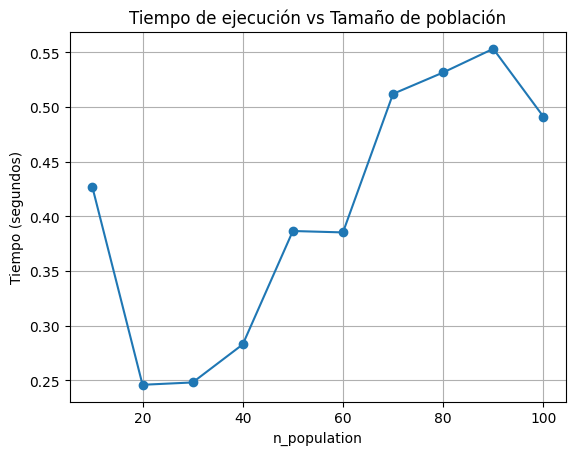

In [6]:
plt.figure()

plt.plot(df["n_population"], df["time"], marker="o")

plt.title("Tiempo de ejecución vs Tamaño de población")
plt.xlabel("n_population")
plt.ylabel("Tiempo (segundos)")
plt.grid(True)

plt.show()

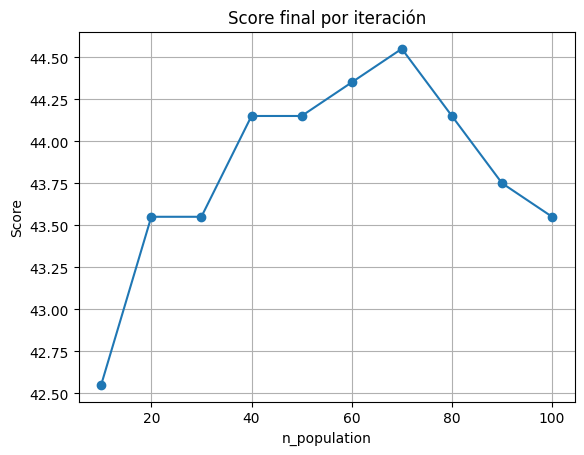

In [7]:
plt.figure()

plt.plot(df["n_population"], df["score"], marker="o")

plt.title("Score final por iteración")
plt.xlabel("n_population")
plt.ylabel("Score")
plt.grid(True)

plt.show()

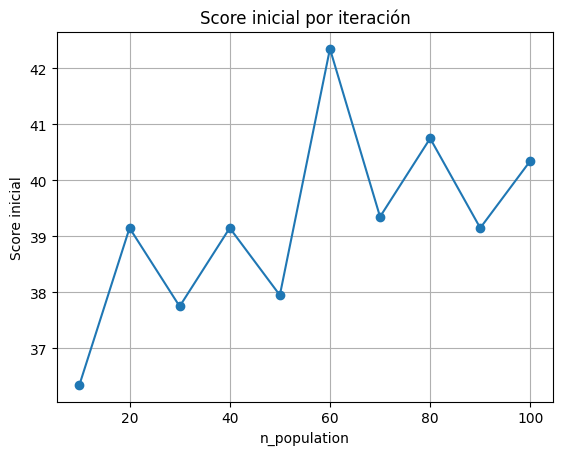

In [8]:
plt.figure()

plt.plot(df["n_population"], df["score_start"], marker="o")

plt.title("Score inicial por iteración")
plt.xlabel("n_population")
plt.ylabel("Score inicial")
plt.grid(True)

plt.show()

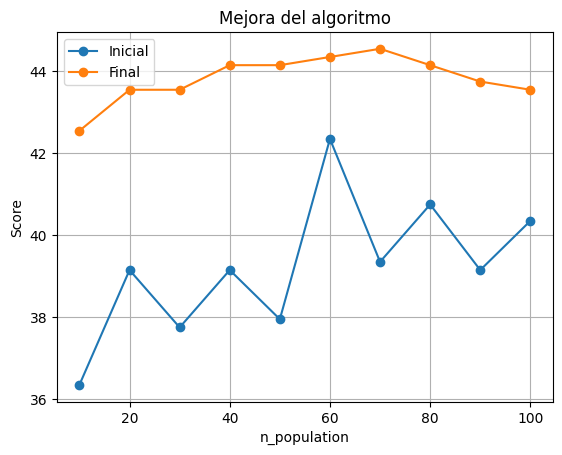

In [9]:
plt.figure()

plt.plot(df["n_population"], df["score_start"], marker="o", label="Inicial")
plt.plot(df["n_population"], df["score"], marker="o", label="Final")

plt.title("Mejora del algoritmo")
plt.xlabel("n_population")
plt.ylabel("Score")

plt.legend()
plt.grid(True)

plt.show()

In [10]:
best_eval = max(eval, key=lambda x: x["score"])
result = best_eval["pairs"]

rows = []
for date_str, tribunal in result.items():
    date, hour = date_str.split("-")
    rows.append({
        "date": int(date),
        "hour": int(hour),
        "President": tribunal["P"],
        "Secretary": tribunal["S"],
        "Vocal": tribunal["V"]
    })

df_pairs = (
    pd.DataFrame(rows)
    .sort_values(["date", "hour"])
    .reset_index(drop=True)
)

# Resultado final

In [11]:
df_pairs

,date,hour,President,Secretary,Vocal
0,15,17,LHL,QYV,EBB
1,15,18,LHL,IOA,PMQ
2,16,15,PMQ,RRD,PMQ
3,16,16,LHL,QYV,MSB
4,16,18,IOE,IOE,HLC
5,17,15,IOA,PMQ,QYV
6,17,16,LHL,IOE,RRD
7,17,21,MSB,HLC,RRD
8,18,17,MSB,EBB,EBB
9,18,19,IOE,IOA,IOA
